In [6]:
import pandas as pd
df = pd.read_csv("../data/student_scores.csv")
print(df.head())
print(df.shape)
df.info()
print(df.describe())

   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30
(25, 2)
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes
           Hours     Scores
count  25.000000  25.000000
mean    5.012000  51.480000
std     2.525094  25.286887
min     1.100000  17.000000
25%     2.700000  30.000000
50%     4.800000  47.000000
75%     7.400000  75.000000
max     9.200000  95.000000


Hours     0
Scores    0
dtype: int64
0
Index(['Hours', 'Scores'], dtype='str')
Hours     float64
Scores      int64
dtype: object
           Hours    Scores
Hours   1.000000  0.976191
Scores  0.976191  1.000000


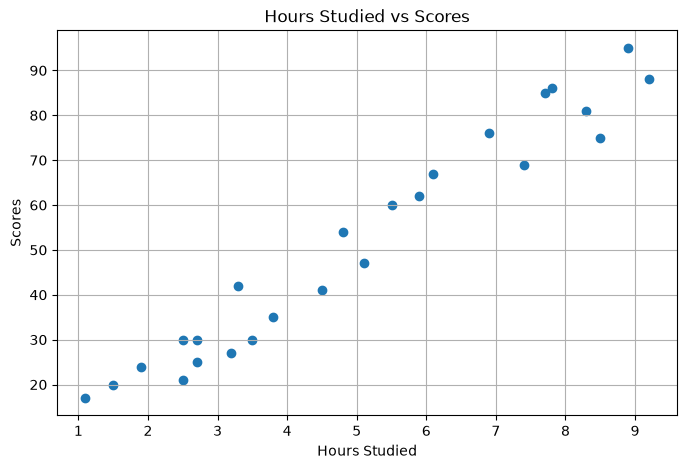

In [7]:
# ==========================================
# Q1. Check for missing values
# ==========================================

print(df.isnull().sum())


# ==========================================
# Q2. Check for duplicate rows
# ==========================================

print(df.duplicated().sum())


# ==========================================
# Q3. Display column names
# ==========================================

print(df.columns)


# ==========================================
# Q4. Display data types
# ==========================================

print(df.dtypes)


# ==========================================
# Q5. Correlation between numerical columns
# ==========================================

print(df.corr(numeric_only=True))


# ==========================================
# Q6. Import Matplotlib
# ==========================================

import matplotlib.pyplot as plt


# ==========================================
# Q7. Scatter Plot
# X-axis = Hours
# Y-axis = Scores
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(df["Hours"], df["Scores"])

plt.title("Hours Studied vs Scores")
plt.xlabel("Hours Studied")
plt.ylabel("Scores")

plt.grid(True)

plt.show()

In [8]:
# ==========================================
# Task 1: Create feature matrix (X) and target vector (y)
# ==========================================

X = df[["Hours"]]
y = df["Scores"]


# ==========================================
# Task 2: Split the dataset
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==========================================
# Task 3: Import and create the Linear Regression model
# ==========================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()


# ==========================================
# Task 4: Train the model
# ==========================================

model.fit(X_train, y_train)


# ==========================================
# Task 5: Predict the scores for the test data
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# Task 6: Print the slope and intercept
# ==========================================

print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)


# ==========================================
# Task 7: Print the predicted values
# ==========================================

print("Predicted Scores:")
print(y_pred)

Slope (Coefficient): 9.682078154455697
Intercept: 2.826892353899737
Predicted Scores:
[83.18814104 27.03208774 27.03208774 69.63323162 59.95115347]


In [9]:
# ==========================================
# Task 1: Import Evaluation Metrics
# ==========================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np


# ==========================================
# Task 2: Calculate MAE
# ==========================================

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)


# ==========================================
# Task 3: Calculate MSE
# ==========================================

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)


# ==========================================
# Task 4: Calculate RMSE
# ==========================================

rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)


# ==========================================
# Task 5: Calculate R² Score
# ==========================================

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


# ==========================================
# Task 6: Create Comparison DataFrame
# ==========================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nComparison of Actual vs Predicted Scores:")
print(comparison)

Mean Absolute Error (MAE): 3.9207511902099244
Mean Squared Error (MSE): 18.943211722315272
Root Mean Squared Error (RMSE): 4.352380006653288
R² Score: 0.9678055545167994

Comparison of Actual vs Predicted Scores:
   Actual  Predicted
0      81  83.188141
1      30  27.032088
2      21  27.032088
3      76  69.633232
4      62  59.951153


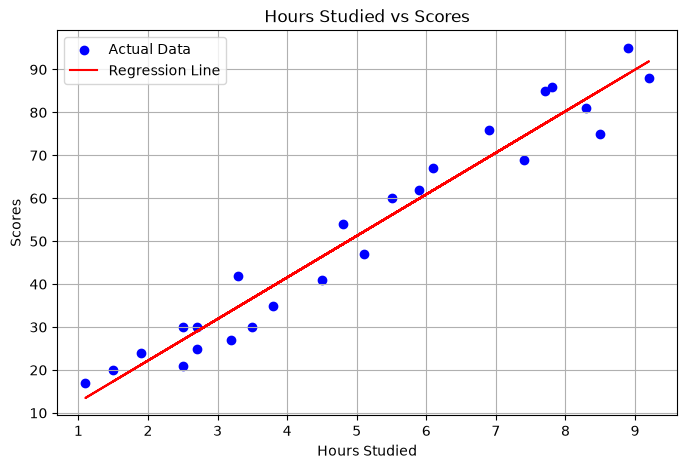

In [10]:
# ==========================================
# Scatter Plot
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(X, y, color="blue", label="Actual Data")


# ==========================================
# Regression Line
# ==========================================

plt.plot(X, model.predict(X), color="red", label="Regression Line")


# ==========================================
# Labels
# ==========================================

plt.title("Hours Studied vs Scores")
plt.xlabel("Hours Studied")
plt.ylabel("Scores")
plt.legend()
plt.grid(True)


# ==========================================
# Show Plot
# ==========================================

plt.show()

In [12]:
import joblib

joblib.dump(model, "StudentScorePrediction.pkl")

print("Model saved successfully!")

Model saved successfully!
